# One-parameter SMC-ABC for k12 with hopping turned off

This notebook performs a **one-parameter inference** for

- `k12` = `base_double_attachment_rate`

using the spatial PRC1 Gillespie model, with:

- all other kinetic parameters fixed,
- a fixed cooperativity energy,
- `enable_cooperativity=True`,
- `enable_hopping=False`.

Before running SMC-ABC, it performs **one timing check** for a single simulation.

## 1. Load local modules

In [1]:
from pathlib import Path
import importlib.util
import inspect
import sys

def load_module(module_name, filename_candidates):
    search_roots = [
        Path.cwd(),
        Path.cwd() / "python_version",
        Path.cwd().parent,
    ]
    for root in search_roots:
        for name in filename_candidates:
            path = root / name
            if path.exists():
                spec = importlib.util.spec_from_file_location(module_name, path)
                module = importlib.util.module_from_spec(spec)
                sys.modules[module_name] = module
                spec.loader.exec_module(module)
                print(f"Loaded {module_name} from: {path}")
                return module
    raise FileNotFoundError(f"Could not find any of: {filename_candidates}")

gillespie = load_module("gillespie", ["gillespie.py", "gillespie(7).py"])
prc1 = load_module("prc1", ["prc1.py", "prc1(7).py"])
prc1_state = load_module("prc1_state", ["prc1_state.py", "prc1_state(7).py"])
run_gillespie = load_module("run_gillespie", ["run_gillespie.py", "run_gillespie(6).py"])
smc_abc = load_module("smc_abc", ["smc_abc.py", "smc-abc.py", "smc-abc(6).py"])

sig = inspect.signature(run_gillespie.run_gillespie_prc1_on_grid)
required_flags = {
    "enable_initial_attach_cooperativity",
    "enable_second_head_attach_cooperativity",
    "enable_second_head_detach_cooperativity",
}
missing = sorted(required_flags - set(sig.parameters))
if missing:
    raise RuntimeError(
        "Your loaded run_gillespie module does not have the new cooperativity flags. "
        f"Missing: {missing}. Make sure you are loading the patched files."
    )

print("Patched cooperativity flags detected successfully.")

Loaded gillespie from: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\gillespie.py
Loaded prc1 from: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\prc1.py
Loaded prc1_state from: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\prc1_state.py
Loaded run_gillespie from: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\run_gillespie.py
Loaded smc_abc from: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\smc-abc.py
Patched cooperativity flags detected successfully.


## 2. Fixed parameters and observation grid

In [2]:
import numpy as np

# fixed model parameters
INIT_BIND = 0.002
K_DET_1 = 0.1
K_DET_2 = 0.1
MAX_STEPS = 200_000

# observation grid
times_obs = np.arange(0.0, 68.0 + 4.0, 4.0)

# thermal scale and fixed cooperativity
k_B_T = 4.1
EPS_FIXED = 2.3 * k_B_T

# true k12 used for synthetic data
K12_TRUE = 5.88

print("times_obs =", times_obs)
print("EPS_FIXED =", EPS_FIXED)
print("K_DET_1 =", K_DET_1)
print("K_DET_2 =", K_DET_2)
print("K12_TRUE =", K12_TRUE)

times_obs = [ 0.  4.  8. 12. 16. 20. 24. 28. 32. 36. 40. 44. 48. 52. 56. 60. 64. 68.]
EPS_FIXED = 9.429999999999998
K_DET_1 = 0.1
K_DET_2 = 0.1
K12_TRUE = 5.88


## 3. Define a one-parameter simulator

Here `theta[0]` is `k12 = base_double_attachment_rate`.
Everything else is fixed, and hopping is disabled.

In [3]:
def simulate_one_k12_attach_only(theta, times_obs, seed):
    """
    theta[0] = k12 = base_double_attachment_rate
    All other parameters are fixed.
    Hopping is disabled.
    Cooperativity acts only in second-head attachment.
    """
    import numpy as np
    np.random.seed(int(seed))

    return run_gillespie.run_gillespie_prc1_on_grid(
        initial_binding_rate_per_site=INIT_BIND,
        singly_bound_detachment_rate=K_DET_1,
        base_double_attachment_rate=float(theta[0]),
        base_double_detachment_rate=K_DET_2,
        times_obs=times_obs,
        cooperativity_energy=EPS_FIXED,
        enable_initial_attach_cooperativity=False,
        enable_second_head_attach_cooperativity=True,
        enable_second_head_detach_cooperativity=False,
        enable_hopping=False,
        max_steps=MAX_STEPS,
    )

## 4. Time one simulation before doing inference

In [4]:
import time

theta_test = np.array([K12_TRUE], dtype=float)

t0 = time.perf_counter()
test_path = simulate_one_k12_attach_only(theta_test, times_obs, seed=123)
t1 = time.perf_counter()

one_sim_seconds = t1 - t0

print("One simulation path:")
print(test_path)
print("Shape:", test_path.shape)
print(f"Time for one simulation: {one_sim_seconds:.6f} seconds")

One simulation path:
[  0.  14.  21.  29.  35.  41.  49.  56.  66.  74.  75.  83.  93. 105.
 114. 125. 134. 145.]
Shape: (18,)
Time for one simulation: 1.326188 seconds


## 5. Patch the SMC-ABC module to use the one-parameter simulator

In [5]:
smc_abc.simulate_one = simulate_one_k12_attach_only
print("Patched smc_abc.simulate_one successfully.")
print("joblib available:", getattr(smc_abc, "_JOBLIB_AVAILABLE", None))

Patched smc_abc.simulate_one successfully.
joblib available: True


## 6. Generate synthetic observed data

In [6]:
n_obs_reps = 10

y_obs = np.array([
    run_gillespie.run_gillespie_prc1_on_grid(
        initial_binding_rate_per_site=INIT_BIND,
        singly_bound_detachment_rate=K_DET_1,
        base_double_attachment_rate=K12_TRUE,
        base_double_detachment_rate=K_DET_2,
        times_obs=times_obs,
        cooperativity_energy=EPS_FIXED,
        enable_initial_attach_cooperativity=False,
        enable_second_head_attach_cooperativity=True,
        enable_second_head_detach_cooperativity=False,
        enable_hopping=False,
        max_steps=MAX_STEPS,
    )
    for _ in range(n_obs_reps)
], dtype=float)

print("y_obs shape:", y_obs.shape)
print(y_obs)

y_obs shape: (10, 18)
[[  0.   6.   9.  21.  33.  43.  51.  65.  73.  87.  94. 102. 106. 115.
  122. 133. 141. 149.]
 [  0.   8.  17.  26.  30.  36.  44.  55.  65.  73.  82.  90.  98. 105.
  111. 115. 119. 124.]
 [  0.   9.  16.  30.  33.  45.  59.  69.  73.  80.  90.  95. 102. 105.
  110. 121. 125. 131.]
 [  0.   9.  22.  34.  44.  48.  60.  66.  76.  80.  86.  95. 105. 110.
  123. 133. 138. 144.]
 [  0.   4.  14.  21.  39.  46.  51.  59.  69.  74.  77.  82.  90.  96.
  102. 112. 120. 121.]
 [  0.   7.  19.  27.  36.  47.  54.  59.  60.  67.  74.  79.  85.  96.
  100. 107. 113. 120.]
 [  0.  17.  33.  45.  51.  58.  70.  78.  86.  89. 103. 110. 113. 118.
  123. 130. 139. 142.]
 [  0.  10.  18.  30.  37.  49.  55.  60.  65.  77.  80.  89.  98. 107.
  116. 126. 140. 148.]
 [  0.   9.  18.  27.  34.  46.  56.  62.  71.  80.  91.  98. 106. 117.
  124. 129. 135. 144.]
 [  0.   6.  11.  17.  27.  39.  47.  56.  59.  65.  71.  80.  86.  99.
  103. 111. 123. 134.]]


## 7. Set a one-parameter prior in log-space

In [7]:
K12_TRUE = 5.88
K12_center = 2.0
phi_mu = np.array([np.log(K12_center)], dtype=float)
phi_sd = np.array([0.5], dtype=float)

## 8. Run SMC-ABC

Set `n_jobs=1` first while debugging.
If the code is stable and your `smc_abc` parallel backend is working, you can change it later.

In [8]:
res = smc_abc.smc_abc_prc1(
    times_obs=times_obs,
    y_obs=y_obs,
    phi_mu=phi_mu,
    phi_sd=phi_sd,
    P=30,
    G=3,
    pool=100,
    n_reps=5,
    eps_quantile=50.0,
    cov_scale=2.0,
    seed=1,
    n_jobs=-1,
    batch_factor=4,
)

print("Finished SMC-ABC.")
print("eps history:", res.eps_history)

Finished SMC-ABC.
eps history: [152.17899061692185, 122.14021719019198, 112.84346025301869]


## 9. Convert posterior particles back to k12 scale

In [9]:
posterior_k12 = np.exp(res.particles_phi[:, 0])
posterior_w = res.weights

print("posterior k12 particles:")
print(posterior_k12)
print("posterior weights:")
print(posterior_w)

posterior k12 particles:
[8.1243775  2.76434621 2.21767551 1.40402084 1.96898243 1.26241715
 4.84387749 4.5545952  2.49297656 7.56741414 3.45057057 2.47398599
 2.71115793 4.49339078 1.82199034 3.06337908 2.18865086 1.19839164
 1.73543669 2.02940181 2.50535108 2.40907815 1.62551696 3.37300364
 1.62828431 2.15571608 6.30842962 4.440823   3.66114773 2.50318137]
posterior weights:
[0.00397399 0.03395668 0.04199246 0.04966164 0.04550158 0.04874949
 0.01389123 0.01569499 0.03789451 0.0048329  0.02530467 0.03817656
 0.03471116 0.01610913 0.04730509 0.02992464 0.04241874 0.04789594
 0.04820342 0.04468773 0.03771102 0.03914376 0.0490973  0.02617396
 0.04907885 0.04289881 0.00770784 0.01647447 0.0230843  0.03774317]


## 10. Posterior summaries

In [10]:
post_mean = np.sum(posterior_w * posterior_k12)

order = np.argsort(posterior_k12)
k12_sorted = posterior_k12[order]
w_sorted = posterior_w[order]
cdf = np.cumsum(w_sorted)
post_median = k12_sorted[np.searchsorted(cdf, 0.5)]

print("True k12:", K12_TRUE)
print("Posterior mean:", post_mean)
print("Posterior median:", post_median)

True k12: 5.88
Posterior mean: 2.3906938759709604
Posterior median: 2.188650864088525


## 11. Posterior plot

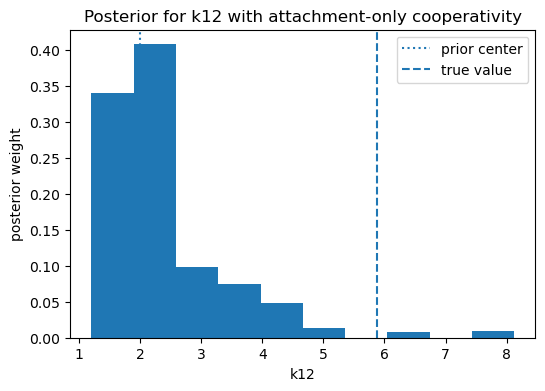

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(posterior_k12, bins=10, weights=posterior_w)
plt.axvline(K12_center, linestyle=":", label="prior center")
plt.axvline(K12_TRUE, linestyle="--", label="true value")
plt.xlabel("k12")
plt.ylabel("posterior weight")
plt.title("Posterior for k12 with attachment-only cooperativity")
plt.legend()
plt.show()

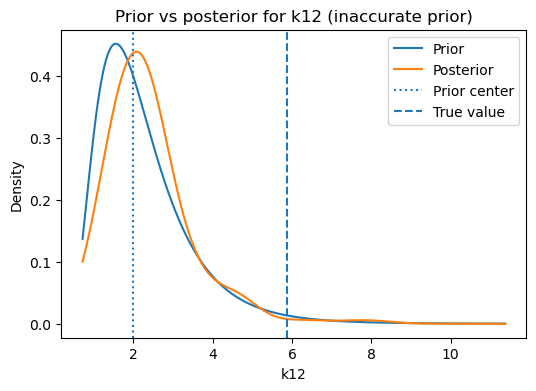

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

posterior_samples = np.asarray(posterior_k12, dtype=float)
posterior_w = np.asarray(posterior_w, dtype=float)

phi0 = float(phi_mu[0])
sd0 = float(phi_sd[0])

def prior_density(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    mask = x > 0
    z = (np.log(x[mask]) - phi0) / sd0
    out[mask] = np.exp(-0.5 * z * z) / (x[mask] * sd0 * np.sqrt(2 * np.pi))
    return out

kde_post = gaussian_kde(posterior_samples, weights=posterior_w)

xmin = min(np.min(posterior_samples), K12_TRUE, K12_center) * 0.6
xmax = max(np.max(posterior_samples), K12_TRUE, K12_center) * 1.4
xmin = max(xmin, 1e-8)

xgrid = np.linspace(xmin, xmax, 500)

prior_y = prior_density(xgrid)
post_y = kde_post(xgrid)

plt.figure(figsize=(6, 4))
plt.plot(xgrid, prior_y, label="Prior")
plt.plot(xgrid, post_y, label="Posterior")
plt.axvline(K12_center, linestyle=":", label="Prior center")
plt.axvline(K12_TRUE, linestyle="--", label="True value")
plt.xlabel("k12")
plt.ylabel("Density")
plt.title("Prior vs posterior for k12 (inaccurate prior)")
plt.legend()
plt.show()